# Erweiterung des Credal-Set-Diversity-Vektors um Diskurskohärenz

Bisher 3D-Vektor:

$$\mathbf{v}_p = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}})$$

Erweiterung: **$D_{\text{disc}}$ — Discourse Diversity**, basierend auf dem **vollständigen Entity-Grid-Modell** (Barzilay & Lapata, 2008).

$$\mathbf{v}_p^{\text{ext}} = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}, \underbrace{D_{\text{disc}}}_{\text{neu}})$$

### Verbesserungen gegenüber dem Prototyp

| Aspekt | Prototyp | Erweitert |
|---|---|---|
| Entity-Grid-Rollen | binär: present (1) / absent (0) | **S**(ubjekt), **O**(bjekt), **X**(sonstige), **–**(absent) |
| Transitionstypen | 4 ($2^2$) | **16** ($4^2$) |
| Entity-Extraktion | NER oder Kapitalisierungs-Heuristik | NER + **Dependency Parsing** für grammatische Rollen |
| Entity-Gewichtung | alle gleich | **Salienz-Gewichtung** (IDF-basiert) + Minimum-Frequenz-Filter |
| Transitionsordnung | Bigramm (Satz $k$ → $k+1$) | Bigramm **+ Trigram** (Satz $k$ → $k+1$ → $k+2$) |
| Satz-Tokenizer | Regex-basiert | **spaCy sentencizer** mit Regex-Fallback |

### Daten
- [`human_drift`](https://github.com/EstebanGarces/human_drift) — 100 Prompts × 10 Stories × 5 Sources
- $D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}$: vorberechnet aus dem Repository

In [1]:
import numpy as np
import json, re, os, time, warnings
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations, product as iterproduct
from collections import Counter, defaultdict
from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from scipy.stats import entropy, mannwhitneyu
from sklearn.decomposition import PCA
from matplotlib.patches import Polygon
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── spaCy laden (NER + Dependency Parsing für grammatische Rollen) ──
USE_SPACY = False
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    USE_SPACY = True
    print('✓ spaCy geladen (en_core_web_sm) — NER + Dependency Parsing aktiv')
except Exception:
    print('⚠ spaCy nicht verfügbar → Kapitalisierungs-Heuristik als Fallback')
    print('  HINWEIS: Ohne spaCy werden grammatische Rollen approximiert.')
    print('  Installieren mit: pip install spacy && python -m spacy download en_core_web_sm')

# ── Konfiguration ──
N_PROMPTS = 100
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
REPO_DIR = Path('../human_drift')

# Entity-Grid-Rollen nach Barzilay & Lapata (2008)
ROLES = ['S', 'O', 'X', '-']  # Subjekt, Objekt, sonstige Rolle, absent
ROLE_S, ROLE_O, ROLE_X, ROLE_ABSENT = 'S', 'O', 'X', '-'

# Alle 16 Bigramm-Transitionen
BIGRAM_TRANSITIONS = [(r1, r2) for r1 in ROLES for r2 in ROLES]
N_BIGRAM = len(BIGRAM_TRANSITIONS)  # 16

# Alle 64 Trigram-Transitionen
TRIGRAM_TRANSITIONS = [(r1, r2, r3) for r1 in ROLES for r2 in ROLES for r3 in ROLES]
N_TRIGRAM = len(TRIGRAM_TRANSITIONS)  # 64

# Entity-Filter
MIN_ENTITY_FREQ = 2  # Entity muss in mindestens 2 Sätzen vorkommen

SOURCE_COLORS = {
    'human': '#1565C0', 'llama': '#E65100',
    'mistral': '#6A1B9A', 'qwen': '#2E7D32', 'gemma': '#C62828',
}

print(f'\nBigramm-Transitionen: {N_BIGRAM} (S/O/X/– × S/O/X/–)')
print(f'Trigram-Transitionen: {N_TRIGRAM} (S/O/X/– × S/O/X/– × S/O/X/–)')

✓ spaCy geladen (en_core_web_sm) — NER + Dependency Parsing aktiv

Bigramm-Transitionen: 16 (S/O/X/– × S/O/X/–)
Trigram-Transitionen: 64 (S/O/X/– × S/O/X/– × S/O/X/–)


## 1. Daten laden

In [2]:
# ============================================================
# 1. DATEN + VORBERECHNETE 3D-METRIKEN
# ============================================================

# Storytelling-Texte aus dem Repo laden
texts = {}
for source in SOURCES:
    fp = REPO_DIR / 'clean_generations' / f'{source}_storytelling_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    texts[source] = {i: raw[p] for i, p in enumerate(prompts)}

# Vorberechnete 3D-Metriken (per-Prompt-Mittelwerte aus dem Repo)
with open(REPO_DIR / 'drift_analysis' / 'per_input_distances.json') as f:
    per_input_3d = json.load(f)

# In Arrays packen: baseline_3d[source] = (100, 3)
baseline_3d = {}
for source in SOURCES:
    sem = per_input_3d[source]['storytelling']['semantic']
    lex = per_input_3d[source]['storytelling']['lexical']
    syn = per_input_3d[source]['storytelling']['syntactic']
    baseline_3d[source] = np.column_stack([sem, lex, syn])

# Statistiken
total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
print(f'{total:,} Texte geladen (100 Prompts × 5 Sources)')
for source in SOURCES:
    means = baseline_3d[source].mean(axis=0)
    print(f'  {source:8s}: Sem={means[0]:.3f}, Lex={means[1]:.3f}, Syn={means[2]:.3f}')

4,994 Texte geladen (100 Prompts × 5 Sources)
  human   : Sem=0.666, Lex=0.985, Syn=0.805
  llama   : Sem=0.352, Lex=0.937, Syn=0.692
  mistral : Sem=0.287, Lex=0.936, Syn=0.671
  qwen    : Sem=0.345, Lex=0.959, Syn=0.704
  gemma   : Sem=0.343, Lex=0.958, Syn=0.685


## 2. $D_{\text{disc}}$ — Vollständiges Entity-Grid-Modell

### Barzilay & Lapata (2008) — Vollständige Implementierung

Jede Entity bekommt pro Satz eine **grammatische Rolle**:

| Rolle | Kürzel | Dependency Labels (spaCy) |
|---|---|---|
| Subjekt | **S** | `nsubj`, `nsubjpass`, `csubj` |
| Objekt | **O** | `dobj`, `iobj`, `pobj`, `attr`, `oprd` |
| Sonstige | **X** | alle anderen grammatischen Relationen |
| Absent | **–** | Entity kommt im Satz nicht vor |

Daraus ergibt sich ein Entity-Grid mit 4 Zuständen:

| | Alice | Bob | Castle |
|---|---|---|---|
| Satz 1 | **S** | **O** | **–** |
| Satz 2 | **S** | **–** | **X** |
| Satz 3 | **–** | **S** | **O** |

**16 Bigramm-Transitionen**: $\{S, O, X, -\}^2$ → Diskurs-Fingerabdruck

**64 Trigram-Transitionen**: $\{S, O, X, -\}^3$ → erfasst längere Diskursmuster

### Entity-Salienz-Gewichtung

Nicht alle Entities sind gleich wichtig. Eine Hauptfigur, die in 15/20 Sätzen vorkommt,
sollte die Transitionen stärker prägen als eine Nebenfigur mit 2 Erwähnungen.

**Gewichtung**: $w_e = \log(1 + \text{freq}(e))$ — logarithmische Frequenzgewichtung,
sodass häufige Entities stärker gewichtet werden, ohne dass Ausreißer dominieren.

### Kombination

$D_{\text{disc}}$ = mittlere paarweise Jensen-Shannon-Divergenz der **gewichteten Bigramm+Trigram-Profile**

In [3]:
# ============================================================
# 2. D_disc IMPLEMENTIERUNG — VOLLSTÄNDIGES ENTITY-GRID-MODELL
# ============================================================

# ── Satz-Tokenizer ──

def sent_tokenize(text):
    """Satz-Tokenizer: spaCy sentencizer oder Regex-Fallback.
    
    spaCy nutzt den Dependency-Parser-basierten Sentencizer,
    der zuverlässiger ist als einfache Regex-Splits (z.B. bei
    Abkürzungen wie 'Dr.', 'Mr.', Ellipsen '...' etc.).
    """
    if USE_SPACY:
        doc = nlp(text)
        sents = [sent.text.strip() for sent in doc.sents]
    else:
        # Fallback: Verbesserter Regex-Tokenizer
        # Schütze Abkürzungen vor falschem Split
        protected = text
        abbrevs = ['Mr.', 'Mrs.', 'Ms.', 'Dr.', 'Prof.', 'Sr.', 'Jr.',
                   'St.', 'vs.', 'etc.', 'e.g.', 'i.e.', 'Lt.', 'Gen.',
                   'Sgt.', 'Cpl.', 'Pvt.', 'Capt.', 'Col.', 'Maj.']
        for abbr in abbrevs:
            protected = protected.replace(abbr, abbr.replace('.', '∎'))
        
        sents_raw = re.split(r'(?<=[.!?])\s+', protected.strip())
        sents = [s.replace('∎', '.').strip() for s in sents_raw]
    
    return [s for s in sents if len(s.strip()) > 5]


# ── Entity-Extraktion mit grammatischen Rollen ──

# Subjekt-Dependencies in spaCy
_SUBJ_DEPS = {'nsubj', 'nsubjpass', 'csubj', 'csubjpass'}
# Objekt-Dependencies in spaCy
_OBJ_DEPS = {'dobj', 'iobj', 'pobj', 'attr', 'oprd', 'dative'}
# NER-Labels die als Entities gelten
_VALID_NER = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT',
              'WORK_OF_ART', 'FAC', 'NORP'}


def _get_role_for_token(token):
    """Bestimme die grammatische Rolle eines Tokens über seinen Dependency-Pfad.
    
    Prüft sowohl das Token selbst als auch seinen Head (für den Fall,
    dass die Entity ein Modifier eines Subjekt/Objekt-Heads ist).
    """
    # Direkte Rolle des Tokens
    if token.dep_ in _SUBJ_DEPS:
        return ROLE_S
    if token.dep_ in _OBJ_DEPS:
        return ROLE_O
    
    # Rolle des Heads prüfen (Entity als Modifier)
    if token.head != token:  # nicht root
        if token.head.dep_ in _SUBJ_DEPS:
            return ROLE_S
        if token.head.dep_ in _OBJ_DEPS:
            return ROLE_O
    
    return ROLE_X


def extract_entity_roles_spacy(sent_doc):
    """Extrahiere Entities mit ihren grammatischen Rollen via spaCy.
    
    Returns:
        dict: {entity_name: role} wobei role ∈ {S, O, X}
        Bei mehreren Rollen einer Entity im selben Satz: Priorität S > O > X
    """
    entity_roles = {}  # entity_name -> role
    role_priority = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1}
    
    for ent in sent_doc.ents:
        if ent.label_ not in _VALID_NER:
            continue
        
        name = ent.text.lower().strip()
        if len(name) < 2:
            continue
        
        # Rolle über den Root-Token der Entity bestimmen
        role = ROLE_X
        for token in ent:
            token_role = _get_role_for_token(token)
            if role_priority.get(token_role, 0) > role_priority.get(role, 0):
                role = token_role
        
        # Höchste Rolle behalten bei Mehrfachvorkommen
        if name not in entity_roles or \
           role_priority[role] > role_priority[entity_roles[name]]:
            entity_roles[name] = role
    
    return entity_roles


# ── Kapitalisierungs-Heuristik als Fallback ──

_COMMON_UPPER = {'the', 'a', 'an', 'i', 'in', 'on', 'at', 'to', 'for',
    'but', 'and', 'or', 'it', 'he', 'she', 'we', 'they', 'my', 'his', 'her',
    'so', 'if', 'as', 'no', 'not', 'all', 'one', 'two', 'first', 'last',
    'just', 'then', 'now', 'here', 'there', 'when', 'where', 'how', 'what',
    'who', 'why', 'this', 'that', 'with', 'from', 'been', 'have', 'has',
    'was', 'were', 'are', 'had', 'would', 'could', 'should', 'will',
    'can', 'may', 'might', 'shall', 'must', 'did', 'does', 'do',
    'said', 'went', 'came', 'back', 'up', 'out', 'off', 'down',
    'over', 'after', 'before', 'still', 'even', 'also', 'very',
    'well', 'right', 'through', 'into', 'about', 'than', 'them',
    'each', 'which', 'their', 'some', 'our', 'your', 'its',
    'once', 'upon', 'time', 'every', 'never', 'always', 'only',
    'many', 'much', 'such', 'like', 'more', 'most', 'own',
}


def extract_entity_roles_heuristic(sentence):
    """Extrahiere Entities via Kapitalisierungs-Heuristik.
    
    Ohne Dependency-Parser können wir grammatische Rollen nur
    approximieren:
    - Erstes kapitalisiertes Wort im Satz → S (Subjekt-Heuristik)
    - Nach Verben → O (Objekt-Heuristik)
    - Sonst → X
    """
    words = sentence.split()
    entity_roles = {}
    found_verb = False
    first_entity = True
    i = 0
    
    # Einfache Verb-Erkennung für Heuristik
    _COMMON_VERBS = {'was', 'were', 'is', 'are', 'had', 'has', 'have',
                     'did', 'does', 'said', 'went', 'came', 'took',
                     'made', 'found', 'knew', 'saw', 'told', 'gave',
                     'felt', 'became', 'left', 'called', 'asked',
                     'looked', 'turned', 'walked', 'stood', 'began'}
    
    while i < len(words):
        word_clean = re.sub(r'[^a-zA-Z]', '', words[i])
        
        if not word_clean:
            i += 1
            continue
        
        # Verb-Tracking für Objekt-Heuristik
        if word_clean.lower() in _COMMON_VERBS:
            found_verb = True
        
        if word_clean[0].isupper() and len(word_clean) > 1 \
           and word_clean.lower() not in _COMMON_UPPER:
            # Multi-Word Entity sammeln
            parts = [word_clean]
            j = i + 1
            while j < len(words):
                nw = re.sub(r'[^a-zA-Z]', '', words[j])
                if nw and nw[0].isupper() and len(nw) > 1 \
                   and nw.lower() not in _COMMON_UPPER:
                    parts.append(nw)
                    j += 1
                else:
                    break
            
            name = ' '.join(parts).lower()
            
            # Rolle zuweisen via Heuristik
            if first_entity and not found_verb:
                role = ROLE_S  # Erste Entity vor dem Verb → Subjekt
            elif found_verb:
                role = ROLE_O  # Nach dem Verb → Objekt
            else:
                role = ROLE_X
            
            entity_roles[name] = role
            first_entity = False
            i = j
        else:
            i += 1
    
    return entity_roles


# ── Entity-Grid Konstruktion ──

def build_entity_grid(text):
    """Konstruiere das vollständige Entity-Grid für einen Text.
    
    Returns:
        grid: dict {entity_name: [role_satz1, role_satz2, ...]}  
              wobei role ∈ {S, O, X, -}
        sents: list der Sätze
        entity_freq: dict {entity_name: Anzahl Sätze mit Vorkommen}
    """
    sents = sent_tokenize(text)
    if len(sents) < 2:
        return {}, sents, {}
    
    # Phase 1: Entity-Rollen pro Satz extrahieren
    sent_entity_roles = []  # list of dicts: {entity: role}
    
    if USE_SPACY:
        # Batch-Processing mit spaCy für Effizienz
        docs = list(nlp.pipe(sents, batch_size=50))
        for doc in docs:
            sent_entity_roles.append(extract_entity_roles_spacy(doc))
    else:
        for s in sents:
            sent_entity_roles.append(extract_entity_roles_heuristic(s))
    
    # Phase 2: Alle Entities sammeln
    all_entities = set()
    for roles in sent_entity_roles:
        all_entities.update(roles.keys())
    
    if not all_entities:
        return {}, sents, {}
    
    # Phase 3: Entity-Grid aufbauen
    grid = {}
    entity_freq = {}  # Anzahl Sätze, in denen Entity vorkommt
    
    for entity in all_entities:
        roles_seq = []
        freq = 0
        for sent_roles in sent_entity_roles:
            if entity in sent_roles:
                roles_seq.append(sent_roles[entity])
                freq += 1
            else:
                roles_seq.append(ROLE_ABSENT)
        
        grid[entity] = roles_seq
        entity_freq[entity] = freq
    
    return grid, sents, entity_freq


def compute_transition_profile(text, use_trigrams=True):
    """Berechne das gewichtete Transitions-Profil für einen Text.
    
    Verwendet:
    - Bigramm-Transitionen (16-dim): Satz k → k+1
    - Trigram-Transitionen (64-dim): Satz k → k+1 → k+2 (optional)
    - Salienz-Gewichtung: w_e = log(1 + freq(e))
    - Minimum-Frequenz-Filter: Entity muss in ≥ MIN_ENTITY_FREQ Sätzen vorkommen
    
    Returns:
        bigram_profile: np.array(16,) — normalisiertes Bigramm-Profil
        trigram_profile: np.array(64,) — normalisiertes Trigram-Profil (oder None)
        grid: das Entity-Grid
        sents: die Sätze
        entity_freq: Entity-Frequenzen
    """
    grid, sents, entity_freq = build_entity_grid(text)
    
    if not grid or len(sents) < 2:
        return (np.ones(N_BIGRAM) / N_BIGRAM,
                np.ones(N_TRIGRAM) / N_TRIGRAM if use_trigrams else None,
                grid, sents, entity_freq)
    
    # Gewichtete Bigramm-Transitionen
    bigram_counts = Counter()
    trigram_counts = Counter()
    
    for entity, roles_seq in grid.items():
        # Minimum-Frequenz-Filter
        if entity_freq[entity] < MIN_ENTITY_FREQ:
            continue
        
        # Salienz-Gewichtung
        weight = np.log(1 + entity_freq[entity])
        
        # Bigramm-Transitionen
        for k in range(len(roles_seq) - 1):
            trans = (roles_seq[k], roles_seq[k+1])
            bigram_counts[trans] += weight
        
        # Trigram-Transitionen
        if use_trigrams and len(roles_seq) >= 3:
            for k in range(len(roles_seq) - 2):
                trans = (roles_seq[k], roles_seq[k+1], roles_seq[k+2])
                trigram_counts[trans] += weight
    
    # Normalisieren
    bigram_total = sum(bigram_counts.values()) or 1
    bigram_profile = np.array([bigram_counts[t] / bigram_total
                               for t in BIGRAM_TRANSITIONS])
    
    trigram_profile = None
    if use_trigrams:
        trigram_total = sum(trigram_counts.values()) or 1
        trigram_profile = np.array([trigram_counts[t] / trigram_total
                                    for t in TRIGRAM_TRANSITIONS])
    
    return bigram_profile, trigram_profile, grid, sents, entity_freq


def jsd(p, q):
    """Jensen-Shannon Divergenz (symmetrisch, [0, ln2])"""
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m) + entropy(q, m))


def discourse_diversity(texts_list, use_trigrams=True, alpha_trigram=0.3):
    """Discourse Diversity: mittlere paarweise JSD der kombinierten Profile.
    
    Kombiniert Bigramm- und Trigram-Profile:
    D_disc = (1 - α) · JSD_bigram + α · JSD_trigram
    
    Args:
        texts_list: Liste von Texten
        use_trigrams: ob Trigram-Transitionen einbezogen werden
        alpha_trigram: Gewicht der Trigram-Komponente (0 = nur Bigram, 1 = nur Trigram)
    """
    profiles_bi = []
    profiles_tri = []
    
    for t in texts_list:
        bi, tri, _, _, _ = compute_transition_profile(t, use_trigrams=use_trigrams)
        profiles_bi.append(bi)
        if tri is not None:
            profiles_tri.append(tri)
    
    profiles_bi = np.array(profiles_bi)
    pairs = list(combinations(range(len(texts_list)), 2))
    
    # Bigramm-JSD
    jsd_bi = np.mean([jsd(profiles_bi[i], profiles_bi[j]) for i, j in pairs])
    
    if use_trigrams and profiles_tri:
        profiles_tri = np.array(profiles_tri)
        jsd_tri = np.mean([jsd(profiles_tri[i], profiles_tri[j]) for i, j in pairs])
        return (1 - alpha_trigram) * jsd_bi + alpha_trigram * jsd_tri
    
    return jsd_bi


print(f'D_disc implementiert (vollständiges Barzilay & Lapata Modell).')
print(f'  Rollen: {ROLES}')
print(f'  Bigramm-Transitionen: {N_BIGRAM}')
print(f'  Trigram-Transitionen: {N_TRIGRAM}')
print(f'  Entity-Filter: min. {MIN_ENTITY_FREQ} Sätze')
print(f'  Gewichtung: log(1 + freq)')
print(f'  spaCy Dep-Parsing: {"aktiv" if USE_SPACY else "Fallback-Heuristik"}')

D_disc implementiert (vollständiges Barzilay & Lapata Modell).
  Rollen: ['S', 'O', 'X', '-']
  Bigramm-Transitionen: 16
  Trigram-Transitionen: 64
  Entity-Filter: min. 2 Sätze
  Gewichtung: log(1 + freq)
  spaCy Dep-Parsing: aktiv


### Beispiel: Entity-Grid mit grammatischen Rollen

Beispieltext: Prompt 0, Story 1
Methode: spaCy NER + Dependency Parsing

Text: 17 Sätze, 12 Entities
Entities (nach Frequenz-Filter ≥ 2):
  dicaprio                  freq= 3  weight=1.39
  kanye                     freq= 2  weight=1.10
  oscar                     freq= 2  weight=1.10

Bigramm-Transitionen (Top 8):
  -→-   : 0.745 ███████████████████████████████████████████████████████████
  O→-   : 0.106 ████████
  -→O   : 0.082 ██████
  S→-   : 0.043 ███
  -→S   : 0.024 █
  S→S   : 0.000 
  S→O   : 0.000 
  S→X   : 0.000 

Trigram-Transitionen (Top 8):
  -→-→-   : 0.728 ██████████████████████████████████████████████████████████
  -→O→-   : 0.087 ██████
  -→-→O   : 0.067 █████
  O→-→S   : 0.026 ██
  O→-→-   : 0.026 ██
  -→S→-   : 0.026 ██
  S→-→-   : 0.020 █
  O→-→O   : 0.020 █


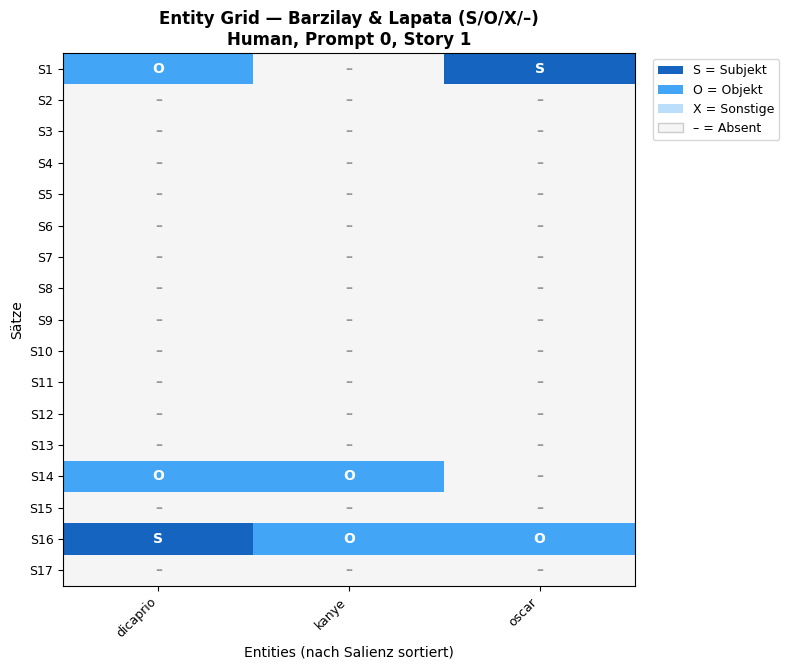

In [4]:
# ============================================================
# BEISPIEL: Entity-Grid mit S/O/X/– Rollen
# ============================================================

example_story = texts['human'][0][1]
example_prompt_idx, example_story_idx = 0, 1
print(f'Beispieltext: Prompt {example_prompt_idx}, Story {example_story_idx}')
print(f'Methode: {"spaCy NER + Dependency Parsing" if USE_SPACY else "Kapitalisierungs-Heuristik"}')

# Profil berechnen
bi_prof, tri_prof, grid, sents, entity_freq = compute_transition_profile(example_story)

print(f'\nText: {len(sents)} Sätze, {len(grid)} Entities')
print(f'Entities (nach Frequenz-Filter ≥ {MIN_ENTITY_FREQ}):')
filtered = {e: f for e, f in entity_freq.items() if f >= MIN_ENTITY_FREQ}
for ent, freq in sorted(filtered.items(), key=lambda x: -x[1])[:10]:
    print(f'  {ent:25s} freq={freq:2d}  weight={np.log(1+freq):.2f}')

# Bigramm-Profil anzeigen
print(f'\nBigramm-Transitionen (Top 8):')
sorted_bi = sorted(zip(BIGRAM_TRANSITIONS, bi_prof), key=lambda x: -x[1])
for trans, prob in sorted_bi[:8]:
    label = f'{trans[0]}→{trans[1]}'
    bar = '█' * int(prob * 80)
    print(f'  {label:6s}: {prob:5.3f} {bar}')

# Trigram-Profil anzeigen
if tri_prof is not None:
    print(f'\nTrigram-Transitionen (Top 8):')
    sorted_tri = sorted(zip(TRIGRAM_TRANSITIONS, tri_prof), key=lambda x: -x[1])
    for trans, prob in sorted_tri[:8]:
        label = f'{trans[0]}→{trans[1]}→{trans[2]}'
        bar = '█' * int(prob * 80)
        print(f'  {label:8s}: {prob:5.3f} {bar}')

# ── Entity-Grid Heatmap mit Rollen ──
if filtered:
    # Sortiere Entities nach Frequenz
    show_ents = sorted(filtered.keys(), key=lambda e: -entity_freq[e])[:15]
    show_sents = min(len(sents), 20)
    
    role_to_num = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1, ROLE_ABSENT: 0}
    role_to_label = {ROLE_S: 'S', ROLE_O: 'O', ROLE_X: 'X', ROLE_ABSENT: '–'}
    
    grid_num = np.zeros((show_sents, len(show_ents)))
    for j, ent in enumerate(show_ents):
        for i in range(show_sents):
            grid_num[i, j] = role_to_num[grid[ent][i]]
    
    # Farben: – = weiß, X = hellblau, O = mittelblau, S = dunkelblau
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#F5F5F5', '#BBDEFB', '#42A5F5', '#1565C0'])
    
    fig, ax = plt.subplots(figsize=(max(8, len(show_ents)*0.9), show_sents*0.4))
    ax.imshow(grid_num, cmap=cmap, aspect='auto', vmin=0, vmax=3)
    ax.set_xticks(range(len(show_ents)))
    ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(show_sents))
    ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=9)
    ax.set_xlabel('Entities (nach Salienz sortiert)')
    ax.set_ylabel('Sätze')
    ax.set_title(
        f'Entity Grid — Barzilay & Lapata (S/O/X/–)\n'
        f'Human, Prompt {example_prompt_idx}, Story {example_story_idx}',
        fontsize=12, fontweight='bold')
    
    for i in range(show_sents):
        for j in range(len(show_ents)):
            role = grid[show_ents[j]][i]
            label = role_to_label[role]
            color = 'white' if role in (ROLE_S, ROLE_O) else '#999999'
            ax.text(j, i, label, ha='center', va='center',
                   fontsize=10, fontweight='bold', color=color)
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1565C0', label='S = Subjekt'),
        Patch(facecolor='#42A5F5', label='O = Objekt'),
        Patch(facecolor='#BBDEFB', label='X = Sonstige'),
        Patch(facecolor='#F5F5F5', edgecolor='#CCCCCC', label='– = Absent'),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              bbox_to_anchor=(1.02, 1), fontsize=9)
    
    plt.tight_layout()
    plt.savefig('example_entity_grid_extended.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Berechnung über alle Prompts und Sources

In [5]:
# ============================================================
# 3. D_disc FÜR ALLE PROMPTS BERECHNEN
# ============================================================

disc_scores = {}  # disc_scores[source] = array(100,)

t0 = time.time()

for source in SOURCES:
    scores = []
    for p in range(N_PROMPTS):
        d = discourse_diversity(texts[source][p],
                                use_trigrams=True, alpha_trigram=0.3)
        scores.append(d)
        if (p + 1) % 25 == 0:
            elapsed = time.time() - t0
            print(f'  {source:8s}: {p+1}/{N_PROMPTS} ({elapsed:.0f}s)')
    disc_scores[source] = np.array(scores)

print(f'\nFertig in {time.time()-t0:.0f}s')

# 4D-Vektor zusammenbauen: baseline_3d + D_disc
results_4d = {}
for source in SOURCES:
    results_4d[source] = np.column_stack([
        baseline_3d[source],
        disc_scores[source]
    ])

METRIC_NAMES = ['Sem', 'Lex', 'Syn', 'Disc']
print(f'\n4D-Vektor: (Sem, Lex, Syn, Disc)')
print(f'{"":<10}', end='')
for s in SOURCES: print(f'{s:>14}', end='')
print()
print('-' * 80)
for i, name in enumerate(METRIC_NAMES):
    print(f'{name:<10}', end='')
    for source in SOURCES:
        m = results_4d[source][:, i].mean()
        s = results_4d[source][:, i].std()
        print(f'{m:>8.4f}±{s:<5.3f}', end='')
    print()

  human   : 25/100 (46s)
  human   : 50/100 (92s)
  human   : 75/100 (133s)
  human   : 100/100 (173s)
  llama   : 25/100 (208s)
  llama   : 50/100 (244s)
  llama   : 75/100 (277s)
  llama   : 100/100 (314s)
  mistral : 25/100 (353s)
  mistral : 50/100 (389s)
  mistral : 75/100 (427s)
  mistral : 100/100 (463s)
  qwen    : 25/100 (491s)
  qwen    : 50/100 (518s)
  qwen    : 75/100 (546s)
  qwen    : 100/100 (574s)
  gemma   : 25/100 (599s)
  gemma   : 50/100 (623s)
  gemma   : 75/100 (649s)
  gemma   : 100/100 (674s)

Fertig in 674s

4D-Vektor: (Sem, Lex, Syn, Disc)
                   human         llama       mistral          qwen         gemma
--------------------------------------------------------------------------------
Sem         0.6664±0.070  0.3519±0.096  0.2866±0.094  0.3455±0.087  0.3432±0.084
Lex         0.9850±0.004  0.9365±0.018  0.9363±0.020  0.9592±0.013  0.9582±0.012
Syn         0.8046±0.016  0.6917±0.032  0.6713±0.024  0.7042±0.026  0.6847±0.026
Disc        0.2250±0.0

## 4. Ergebnisse: Ist $D_{\text{disc}}$ informativ?

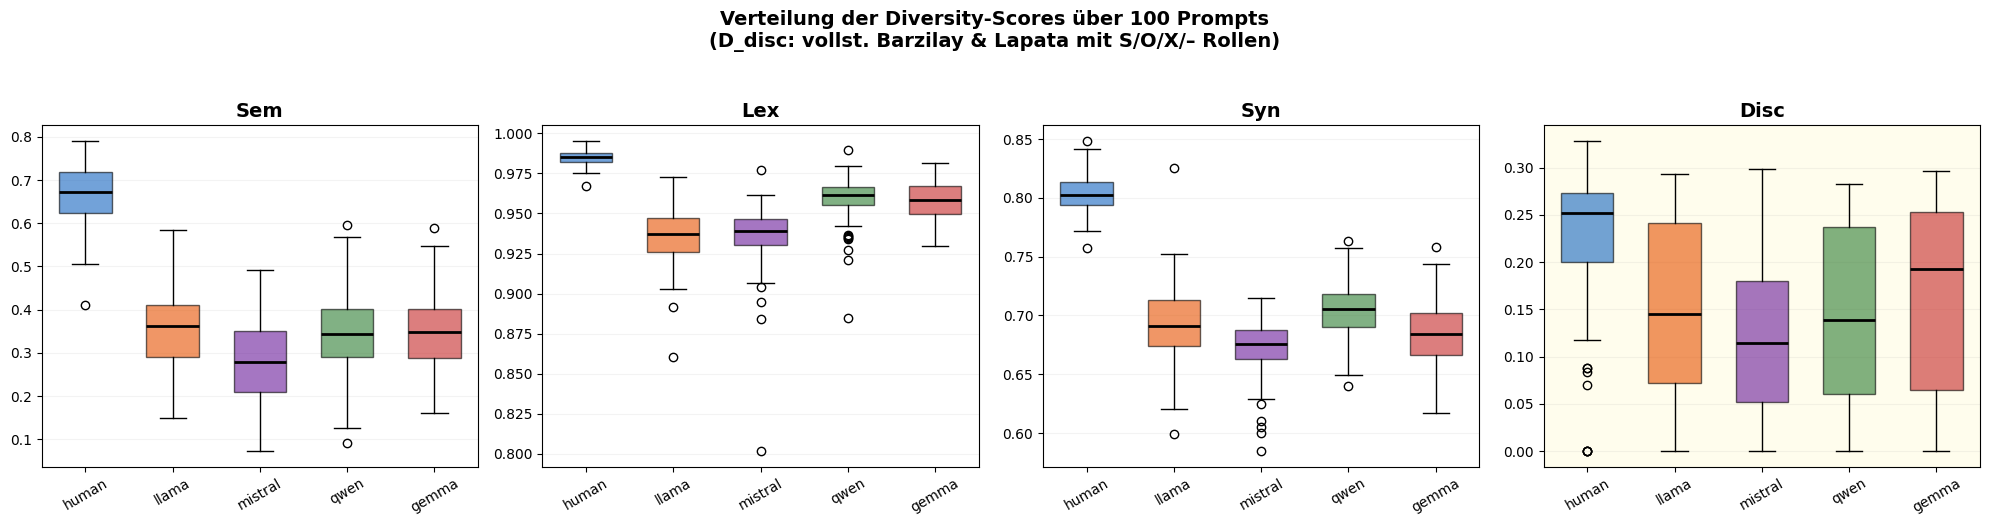

In [6]:
# ============================================================
# 4a. BOXPLOT: D_disc über 5 Sources
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (name, ax) in enumerate(zip(METRIC_NAMES, axes)):
    data = [results_4d[s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')
    if name == 'Disc':
        ax.patch.set_facecolor('#FFF9C4')
        ax.patch.set_alpha(0.3)

fig.suptitle('Verteilung der Diversity-Scores über 100 Prompts\n'
             '(D_disc: vollst. Barzilay & Lapata mit S/O/X/– Rollen)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('diversity_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

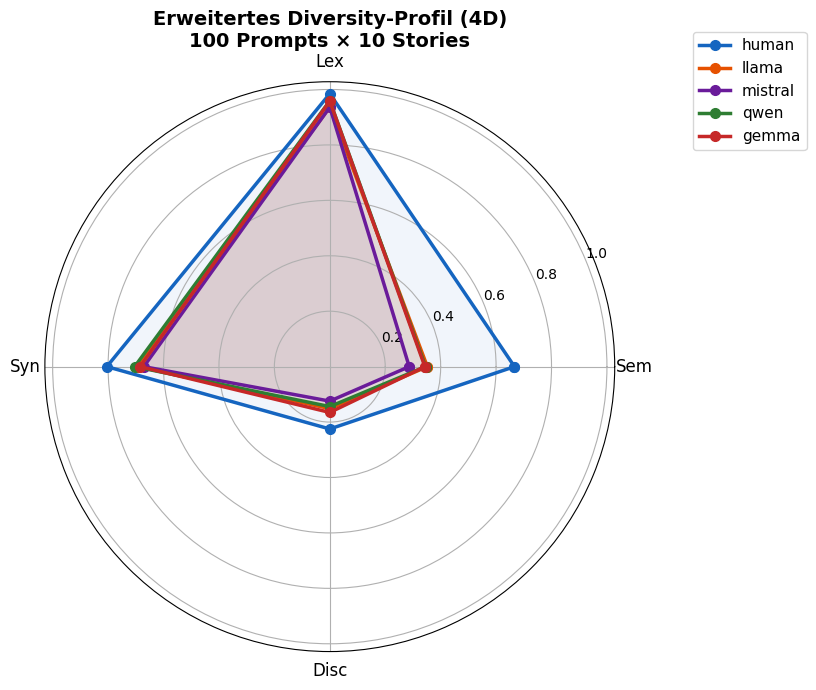

In [7]:
# ============================================================
# 4b. RADAR CHART: 4D-Profil
# ============================================================

angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))

for source in SOURCES:
    means = results_4d[source].mean(axis=0)
    values = means.tolist() + [means[0]]
    ax.plot(angles, values, 'o-', color=SOURCE_COLORS[source],
            linewidth=2.5, label=source, markersize=7)
    ax.fill(angles, values, alpha=0.06, color=SOURCE_COLORS[source])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_title('Erweitertes Diversity-Profil (4D)\n100 Prompts × 10 Stories',
             fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('diversity_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

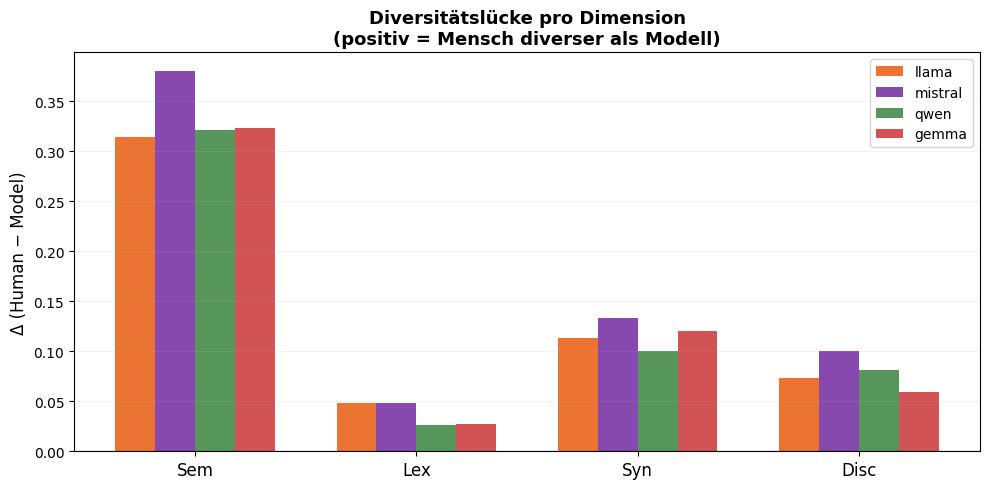

In [8]:
# ============================================================
# 4c. DIVERSITÄTSLÜCKE: Human - Modell pro Dimension
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(4)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    deltas = results_4d['human'].mean(axis=0) - results_4d[source].mean(axis=0)
    ax.bar(x + j*width, deltas, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_ylabel('Δ (Human − Model)', fontsize=12)
ax.set_title('Diversitätslücke pro Dimension\n(positiv = Mensch diverser als Modell)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig('diversity_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# 4d. EFFEKTSTÄRKE: Mann-Whitney U + Cohen's d
# ============================================================

def cohens_d(a, b):
    """Cohen's d Effektstärke"""
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

print('Effektstärke Human vs. Modell — D_disc')
print(f'{"Modell":<10} {"Cohen d":>10} {"Stärke":>10} {"U-test p":>12}')
print('-' * 46)

h_disc = disc_scores['human']
for source in SOURCES[1:]:
    m_disc = disc_scores[source]
    d = cohens_d(h_disc, m_disc)
    _, p_val = mannwhitneyu(h_disc, m_disc, alternative='two-sided')
    strength = 'groß' if abs(d) > 0.8 else 'mittel' if abs(d) > 0.5 else 'klein'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')

Effektstärke Human vs. Modell — D_disc
Modell        Cohen d     Stärke     U-test p
----------------------------------------------
llama          +0.920       groß     5.19e-09
mistral        +1.301       groß     2.04e-14
qwen           +0.983       groß     7.31e-11
gemma          +0.706     mittel     5.86e-06


## 5. Korrelation: Ist $D_{\text{disc}}$ orthogonal zu den bestehenden Metriken?

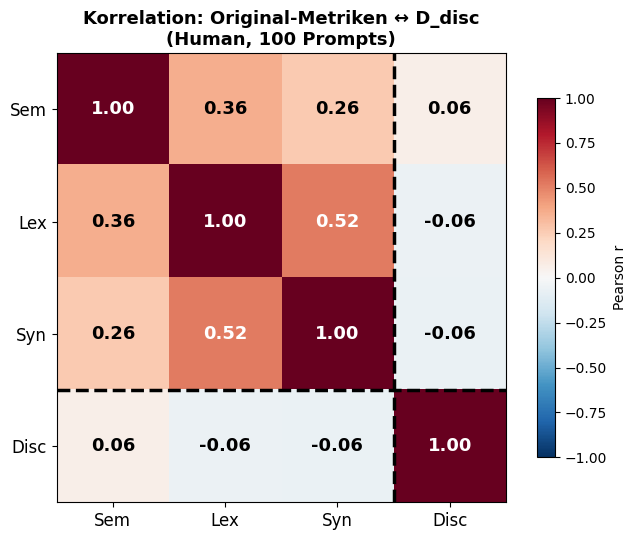

Korrelationen mit D_disc:
  Sem–Disc: r = +0.056 (schwach)
  Lex–Disc: r = -0.062 (schwach)
  Syn–Disc: r = -0.065 (schwach)


In [10]:
# ============================================================
# 5. KORRELATIONSANALYSE
# ============================================================

human_4d = results_4d['human']
corr = np.corrcoef(human_4d.T)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_yticklabels(METRIC_NAMES, fontsize=12)
for i in range(4):
    for j in range(4):
        c = 'white' if abs(corr[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color=c, fontweight='bold')
ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title('Korrelation: Original-Metriken ↔ D_disc\n(Human, 100 Prompts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Korrelationen mit D_disc:')
for i, name in enumerate(METRIC_NAMES[:3]):
    r = corr[i, 3]
    strength = 'stark' if abs(r) > 0.5 else 'moderat' if abs(r) > 0.3 else 'schwach'
    print(f'  {name}–Disc: r = {r:+.3f} ({strength})')

## 6. PCA: Was bringt die vierte Dimension?

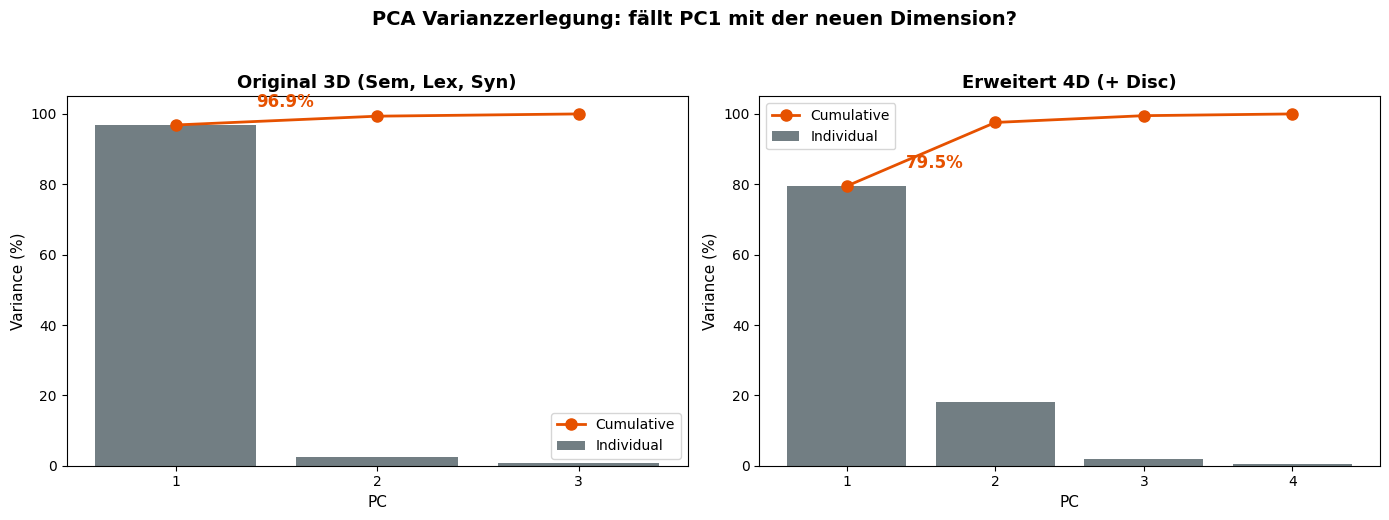

PC1 Varianzanteil:
  3D (Paper):    96.9%
  4D (+ Disc):   79.5%
  Paper (Ref):   85.8%

→ Abfall: 17.4% = D_disc bringt orthogonale Information


In [11]:
# ============================================================
# 6. PCA: 3D vs 4D
# ============================================================

all_4d = np.vstack([results_4d[s] for s in SOURCES])
all_3d = all_4d[:, :3]

pca_3d = PCA().fit(all_3d)
pca_4d = PCA().fit(all_4d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d, 'Original 3D (Sem, Lex, Syn)', 3),
    (axes[1], pca_4d, 'Erweitert 4D (+ Disc)', 4),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC', fontsize=11); ax.set_ylabel('Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=10)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.4, var[0]+5),
                fontsize=12, fontweight='bold', color='#E65100')

plt.suptitle('PCA Varianzzerlegung: fällt PC1 mit der neuen Dimension?',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 Varianzanteil:')
print(f'  3D (Paper):    {pca_3d.explained_variance_ratio_[0]:.1%}')
print(f'  4D (+ Disc):   {pca_4d.explained_variance_ratio_[0]:.1%}')
print(f'  Paper (Ref):   85.8%')
print(f'\n→ Abfall: {pca_3d.explained_variance_ratio_[0] - pca_4d.explained_variance_ratio_[0]:.1%} '
      f'= D_disc bringt orthogonale Information')

## 7. Credal Sets: 3D vs 4D

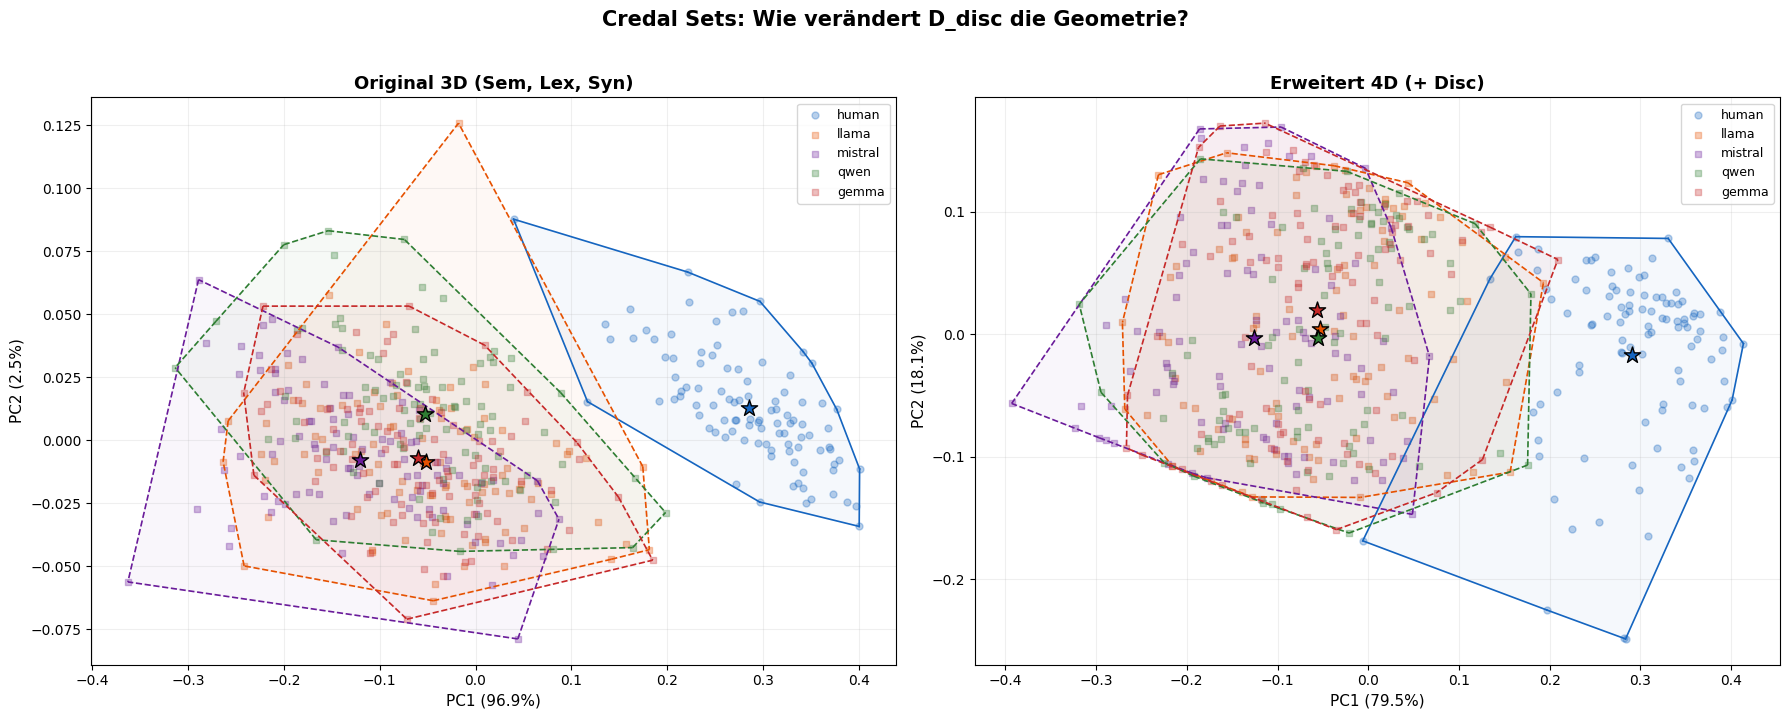

In [12]:
# ============================================================
# 7. CREDAL SETS (side-by-side: 3D vs 4D)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data_dict, title in [
    (axes[0], {s: results_4d[s][:, :3] for s in SOURCES}, 'Original 3D (Sem, Lex, Syn)'),
    (axes[1], results_4d, 'Erweitert 4D (+ Disc)'),
]:
    all_data = np.vstack([data_dict[s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    
    for i, source in enumerate(SOURCES):
        n = len(data_dict[source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Credal Sets: Wie verändert D_disc die Geometrie?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 7b. OVERLAP-KOEFFIZIENTEN: 3D vs 4D
# ============================================================

def overlap_coefficient(points_a, points_b):
    dists_ab = cdist(points_a, points_b)
    dists_ba = cdist(points_b, points_a)

    all_pts = np.vstack([points_a, points_b])
    all_d = cdist(all_pts, all_pts)
    np.fill_diagonal(all_d, np.inf)

    theta = 0.5 * np.mean(all_d.min(axis=1))
    
    a_near = np.mean(dists_ab.min(axis=1) < theta)
    b_near = np.mean(dists_ba.min(axis=1) < theta)

    return 0.5 * (a_near + b_near)


print('Kalibrierung: Overlap Human ↔ Modell')
print(f'{"Modell":<10} {"3D (orig)":>10} {"4D (+Disc)":>12} {"Δ":>8}')
print('-' * 44)

h = results_4d['human']
for source in SOURCES[1:]:
    m = results_4d[source]
    ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
    ov_4d = overlap_coefficient(h, m)
    delta = ov_4d - ov_3d
    print(f'{source:<10} {ov_3d:>10.3f} {ov_4d:>12.3f} {delta:>+8.3f}')

Kalibrierung: Overlap Human ↔ Modell
Modell      3D (orig)   4D (+Disc)        Δ
--------------------------------------------
llama           0.000        0.000   +0.000
mistral         0.000        0.000   +0.000
qwen            0.000        0.000   +0.000
gemma           0.000        0.000   +0.000


## 8. Credal Sets für $D_{\text{disc}}$

1. Pro Prompt: alle $\binom{10}{2} = 45$ paarweisen JSD-Distanzen zwischen den Entity-Grid-Profilen
2. **Gepoolter Rang-Transform** über alle Sources
3. **K = 15 Bins** auf [0,1] + Laplace-Glättung (α = 1) → Simplex-Punkt auf $\Delta^{14}$
4. **Credal Set** = konvexe Hülle aller 100 Simplex-Punkte pro Source
5. **PCA** → 2D-Projektion

In [14]:
# ============================================================
# 8a. PAARWEISE JSD-DISTANZEN + SIMPLEX-PUNKTE
# ============================================================

K_BINS_DISC = 15
ALPHA_SMOOTH = 1.0
BIN_EDGES = np.linspace(0, 1, K_BINS_DISC + 1)

def pairwise_jsd_disc(texts_list, use_trigrams=True, alpha_trigram=0.3):
    """Paarweise JSD-Distanzen zwischen den kombinierten Profilen für einen Prompt."""
    profiles = []
    
    for t in texts_list:
        bi, tri, _, _, _ = compute_transition_profile(t, use_trigrams=use_trigrams)
        if use_trigrams and tri is not None:
            # Kombiniertes Profil: Bigramm + gewichtetes Trigram
            combined = np.concatenate([
                (1 - alpha_trigram) * bi,
                alpha_trigram * tri
            ])
        else:
            combined = bi
        profiles.append(combined)
    
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.array([jsd(profiles[i], profiles[j]) for i, j in pairs])

# Paarweise Distanzen für alle Prompts × Sources
raw_disc_dists = {}  # raw_disc_dists[source] = list of (45,) arrays
t0 = time.time()

for source in SOURCES:
    raw_disc_dists[source] = [
        pairwise_jsd_disc(texts[source][p]) for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: fertig ({time.time()-t0:.0f}s)')

print(f'\nDistanzen berechnet in {time.time()-t0:.0f}s')

# Gepoolter Rang-Transform (alle Sources zusammen)
all_raw = np.concatenate([np.concatenate(raw_disc_dists[s]) for s in SOURCES])
sorted_ref = np.sort(all_raw)

def rank_transform(values):
    return np.searchsorted(sorted_ref, values, side='right') / len(sorted_ref)

def dist_to_simplex(distances):
    ranked = rank_transform(distances)
    counts, _ = np.histogram(ranked, bins=BIN_EDGES)
    smoothed = counts + ALPHA_SMOOTH
    return smoothed / smoothed.sum()

# Simplex-Punkte: disc_simplex[source] = (100, 15)
disc_simplex = {
    s: np.array([dist_to_simplex(raw_disc_dists[s][p]) for p in range(N_PROMPTS)])
    for s in SOURCES
}

print(f'Simplex-Punkte: {list(disc_simplex.values())[0].shape}')
print(f'Mittlere Distanz pro Source:')
for s in SOURCES:
    mean_d = np.concatenate(raw_disc_dists[s]).mean()
    print(f'  {s:8s}: {mean_d:.4f}')

  human   : fertig (166s)
  llama   : fertig (305s)
  mistral : fertig (451s)
  qwen    : fertig (562s)
  gemma   : fertig (660s)

Distanzen berechnet in 660s
Simplex-Punkte: (100, 15)
Mittlere Distanz pro Source:
  human   : 0.2562
  llama   : 0.1698
  mistral : 0.1350
  qwen    : 0.1619
  gemma   : 0.1917


PCA: PC1=40.9%, PC2=18.4%


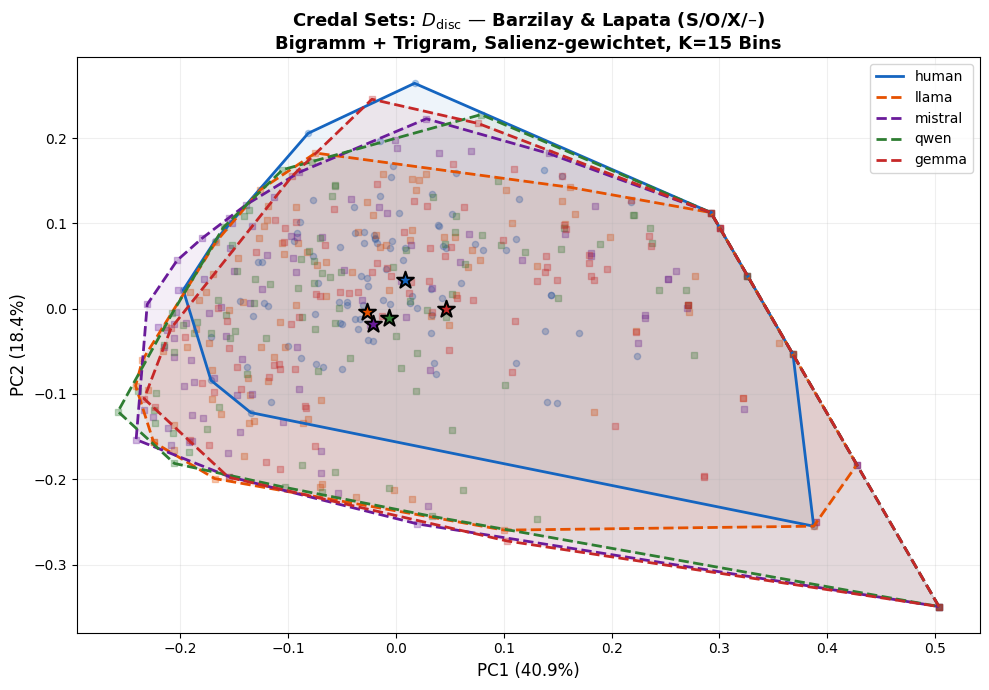

In [15]:
# =====================================
# 8b. CREDAL SETS: PCA + KONVEXE HÜLLE 
# =====================================

all_simplex_pts = np.vstack([disc_simplex[s] for s in SOURCES])
pca_disc = PCA(n_components=2)
pca_disc.fit(all_simplex_pts)
disc_2d = {s: pca_disc.transform(disc_simplex[s]) for s in SOURCES}

print(f'PCA: PC1={pca_disc.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2={pca_disc.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))

for source in SOURCES:
    pts = disc_2d[source]
    ls = '-' if source == 'human' else '--'
    marker = 'o' if source == 'human' else 's'
    ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source],
               alpha=0.3, s=20, marker=marker)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, c=SOURCE_COLORS[source], s=160, marker='*',
               edgecolors='black', linewidth=1.5, zorder=6)
    try:
        hull = ConvexHull(pts)
        hull_idx = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                alpha=0.07, color=SOURCE_COLORS[source])
        ax.plot(pts[hull_idx, 0], pts[hull_idx, 1],
                color=SOURCE_COLORS[source], linewidth=2,
                linestyle=ls, label=source)
    except Exception:
        pass

ax.set_xlabel(f'PC1 ({pca_disc.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_disc.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(
    'Credal Sets: $D_{\\text{disc}}$ — Barzilay & Lapata (S/O/X/–)\n'
    'Bigramm + Trigram, Salienz-gewichtet, K=15 Bins',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Ablationsstudie: Beitrag der einzelnen Erweiterungen

Vergleich der Diskriminierungsfähigkeit verschiedener Entity-Grid-Konfigurationen:

| Konfiguration | Rollen | Transitionen | Gewichtung |
|---|---|---|---|
| (A) Prototyp | binär (0/1) | 4 Bigramm | keine |
| (B) + Rollen | S/O/X/– | 16 Bigramm | keine |
| (C) + Gewichtung | S/O/X/– | 16 Bigramm | Salienz |
| (D) + Trigram | S/O/X/– | 16 Bi + 64 Tri | Salienz |

In [16]:
# ============================================================
# 9. ABLATIONSSTUDIE
# ============================================================

def compute_profile_binary(text):
    """Prototyp-Profil: binär (0/1), 4 Transitionen, ungewichtet."""
    grid, sents, entity_freq = build_entity_grid(text)
    if not grid or len(sents) < 2:
        return np.ones(4) / 4
    
    trans = Counter()
    for entity, roles_seq in grid.items():
        binary = [0 if r == ROLE_ABSENT else 1 for r in roles_seq]
        for k in range(len(binary) - 1):
            trans[(binary[k], binary[k+1])] += 1
    
    total = sum(trans.values()) or 1
    binary_types = [(0,0), (0,1), (1,0), (1,1)]
    return np.array([trans[t] / total for t in binary_types])


def compute_profile_roles_unweighted(text):
    """16 Bigramm-Transitionen mit S/O/X/–, aber ohne Gewichtung."""
    grid, sents, entity_freq = build_entity_grid(text)
    if not grid or len(sents) < 2:
        return np.ones(N_BIGRAM) / N_BIGRAM
    
    trans = Counter()
    for entity, roles_seq in grid.items():
        for k in range(len(roles_seq) - 1):
            trans[(roles_seq[k], roles_seq[k+1])] += 1  # kein weight
    
    total = sum(trans.values()) or 1
    return np.array([trans[t] / total for t in BIGRAM_TRANSITIONS])


def compute_profile_roles_weighted(text):
    """16 Bigramm-Transitionen mit S/O/X/–, Salienz-gewichtet."""
    bi, _, _, _, _ = compute_transition_profile(text, use_trigrams=False)
    return bi


# Ablation berechnen
ablation_configs = [
    ('(A) Prototyp',      compute_profile_binary),
    ('(B) + Rollen',      compute_profile_roles_unweighted),
    ('(C) + Gewichtung',  compute_profile_roles_weighted),
]

# Für jede Konfiguration: mittlere JSD zwischen Human und allen Modellen
print('Ablationsstudie: Mittlere JSD (Human vs. Modell) pro Konfiguration')
print(f'{"":<20}', end='')
for s in SOURCES[1:]: print(f'{s:>12}', end='')
print(f'{"Mittel":>12}')
print('-' * 72)

ablation_results = {}
for config_name, profile_fn in ablation_configs:
    # Profile für alle Texte berechnen (Stichprobe: 20 Prompts für Speed)
    sample_prompts = list(range(0, N_PROMPTS, 5))[:20]
    jsds_per_model = {}
    
    for model in SOURCES[1:]:
        jsds = []
        for p in sample_prompts:
            h_profiles = [profile_fn(t) for t in texts['human'][p]]
            m_profiles = [profile_fn(t) for t in texts[model][p]]
            # Mittlere JSD zwischen Human- und Modell-Profilen
            for hi, mi in zip(h_profiles, m_profiles):
                jsds.append(jsd(hi, mi))
        jsds_per_model[model] = np.mean(jsds)
    
    mean_all = np.mean(list(jsds_per_model.values()))
    print(f'{config_name:<20}', end='')
    for s in SOURCES[1:]:
        print(f'{jsds_per_model[s]:>12.4f}', end='')
    print(f'{mean_all:>12.4f}')
    ablation_results[config_name] = {**jsds_per_model, 'mean': mean_all}

# Config D (vollständig) separat, da andere Profil-Struktur
jsds_per_model_d = {}
sample_prompts = list(range(0, N_PROMPTS, 5))[:20]
for model in SOURCES[1:]:
    jsds = []
    for p in sample_prompts:
        h_profiles = []
        m_profiles = []
        for t in texts['human'][p]:
            bi, tri, _, _, _ = compute_transition_profile(t, use_trigrams=True)
            h_profiles.append(np.concatenate([0.7 * bi, 0.3 * tri]))
        for t in texts[model][p]:
            bi, tri, _, _, _ = compute_transition_profile(t, use_trigrams=True)
            m_profiles.append(np.concatenate([0.7 * bi, 0.3 * tri]))
        for hi, mi in zip(h_profiles, m_profiles):
            jsds.append(jsd(hi, mi))
    jsds_per_model_d[model] = np.mean(jsds)

mean_d = np.mean(list(jsds_per_model_d.values()))
print(f'{"(D) + Trigram":<20}', end='')
for s in SOURCES[1:]:
    print(f'{jsds_per_model_d[s]:>12.4f}', end='')
print(f'{mean_d:>12.4f}')
ablation_results['(D) + Trigram'] = {**jsds_per_model_d, 'mean': mean_d}

print(f'\n→ Höhere JSD = bessere Diskriminierung zwischen Human und Modell')

Ablationsstudie: Mittlere JSD (Human vs. Modell) pro Konfiguration
                           llama     mistral        qwen       gemma      Mittel
------------------------------------------------------------------------
(A) Prototyp              0.0744      0.1027      0.1004      0.0943      0.0929
(B) + Rollen              0.1450      0.1959      0.1959      0.1838      0.1802
(C) + Gewichtung          0.1871      0.2083      0.2461      0.1958      0.2093
(D) + Trigram             0.2329      0.2654      0.2989      0.2475      0.2612

→ Höhere JSD = bessere Diskriminierung zwischen Human und Modell


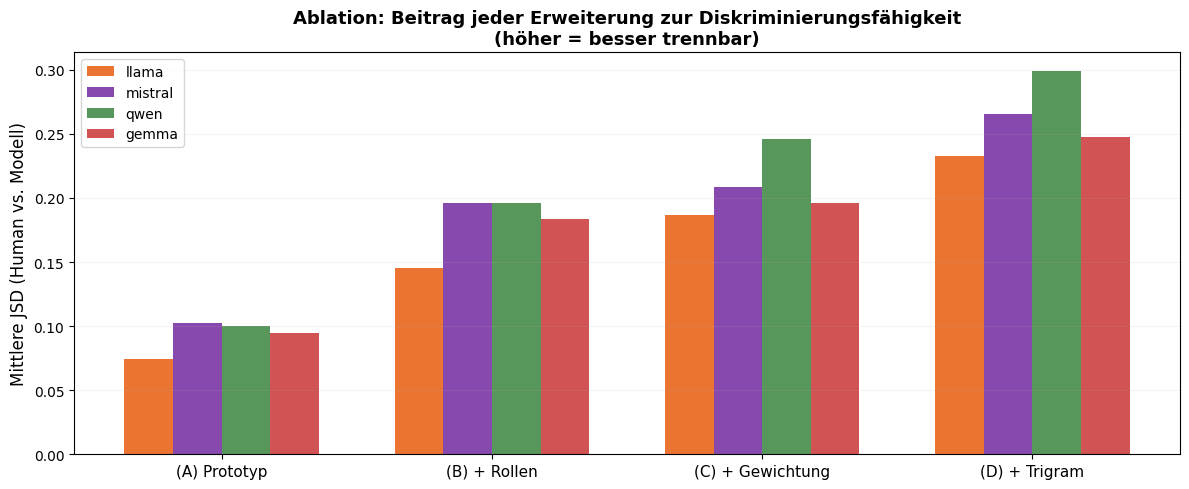

In [17]:
# ============================================================
# 9b. ABLATION VISUALISIERUNG
# ============================================================

config_names = list(ablation_results.keys())
x = np.arange(len(config_names))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))

for j, model in enumerate(SOURCES[1:]):
    vals = [ablation_results[c][model] for c in config_names]
    ax.bar(x + j*width, vals, width, label=model,
           color=SOURCE_COLORS[model], alpha=0.8)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(config_names, fontsize=11)
ax.set_ylabel('Mittlere JSD (Human vs. Modell)', fontsize=12)
ax.set_title('Ablation: Beitrag jeder Erweiterung zur Diskriminierungsfähigkeit\n'
             '(höher = besser trennbar)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Zusammenfassung & Ergebnisse speichern

In [ ]:
# ============================================================
# 10. ERGEBNISSE SPEICHERN
# ============================================================

output = {
    'metric_names': METRIC_NAMES,
    'sources': SOURCES,
    'n_prompts': N_PROMPTS,
    'model_config': {
        'roles': ROLES,
        'n_bigram_transitions': N_BIGRAM,
        'n_trigram_transitions': N_TRIGRAM,
        'min_entity_freq': MIN_ENTITY_FREQ,
        'salience_weighting': 'log(1 + freq)',
        'alpha_trigram': 0.3,
        'entity_extraction': 'spaCy NER + Dependency Parsing' if USE_SPACY else 'Kapitalisierungs-Heuristik',
        'reference': 'Barzilay & Lapata (2008), Modeling Local Coherence: An Entity-Based Approach',
    },
    'results_4d': {s: results_4d[s].tolist() for s in SOURCES},
    'disc_scores': {s: disc_scores[s].tolist() for s in SOURCES},
    'correlation_matrix': corr.tolist(),
    'pca_3d_pc1': float(pca_3d.explained_variance_ratio_[0]),
    'pca_4d_pc1': float(pca_4d.explained_variance_ratio_[0]),
    'ablation': {k: v for k, v in ablation_results.items()},
}

with open('disc_diversity_results_extended.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Ergebnisse gespeichert: disc_diversity_results_extended.json')

Ergebnisse gespeichert: disc_diversity_results_extended.json

══════════════════════════════════════════════════════════════════════
ZUSAMMENFASSUNG: D_disc — Vollständiges Entity-Grid-Modell
══════════════════════════════════════════════════════════════════════

  Modell:    Barzilay & Lapata (2008)
  Rollen:    S (Subjekt), O (Objekt), X (Sonstige), – (Absent)
  Bigramm:   16 Transitionstypen
  Trigram:    64 Transitionstypen (α = 0.3)
  Entities:  NER + Dep-Parsing, min. freq ≥ 2
  Gewichtung: log(1 + freq) Salienz-Gewichtung

  Korrelation mit bestehenden Metriken:
    Sem–Disc: r = +0.056
    Lex–Disc: r = -0.062
    Syn–Disc: r = -0.065

  PCA PC1-Abfall: 96.9% → 79.5%
  → D_disc bringt 17.4% orthogonale Information
